# Notebook 1 - Data_Audit
Objective

• Understand the structure and quality of the Online Retail dataset.

• Identify and handle missing values, duplicates, and invalid transactions.

• Prepare a clean dataset for snapshot creation and feature engineering.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Project files/online_retail_II.xlsx"

xls = pd.ExcelFile(file_path)

df_list = [
    pd.read_excel(file_path, sheet_name=sheet)
    for sheet in xls.sheet_names
]

retail = pd.concat(df_list, ignore_index=True)

print(retail.shape)
retail.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Keep only rows with a valid customer ID.
# Why:
# customer-level modeling is impossible without customer identity.
retail = retail[retail["Customer ID"].notna()].copy()

# Convert customer ID to integer/string for stable grouping.
retail["Customer ID"] = retail["Customer ID"].astype(int).astype(str)

# Convert invoice date to datetime.
# Why:
# we need proper dates for snapshot and repeat-customer analysis.
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])

# Remove cancellations.
# In this dataset, invoice numbers starting with 'C' indicate cancellations.
retail = retail[~retail["Invoice"].astype(str).str.startswith("C")].copy()

# Remove non-positive quantity and unit price.
# Why:
# we want valid completed purchase lines only.
retail = retail[retail["Quantity"] > 0].copy()
retail = retail[retail["Price"] > 0].copy()

# Create transaction revenue.
retail["Revenue"] = retail["Quantity"] * retail["Price"]

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [ ]:
# Keep only rows with a valid customer ID.
# Why:
# customer-level modeling is impossible without customer identity.
retail = retail[retail["Customer ID"].notna()].copy()

# Convert customer ID to integer/string for stable grouping.
retail["Customer ID"] = retail["Customer ID"].astype(int).astype(str)

# Convert invoice date to datetime.
# Why:
# we need proper dates for snapshot and repeat-customer analysis.
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])

# Remove cancellations.
# In this dataset, invoice numbers starting with 'C' indicate cancellations.
retail = retail[~retail["Invoice"].astype(str).str.startswith("C")].copy()

# Remove non-positive quantity and unit price.
# Why:
# we want valid completed purchase lines only.
retail = retail[retail["Quantity"] > 0].copy()
retail = retail[retail["Price"] > 0].copy()

# Create transaction revenue.
retail["Revenue"] = retail["Quantity"] * retail["Price"]

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [ ]:
# Basic dataset stats after cleaning
print("Cleaned shape:", retail.shape)
print("Unique customers:", retail["Customer ID"].nunique())
print("Unique invoices:", retail["Invoice"].nunique())
print("Date range:", retail["InvoiceDate"].min(), "to", retail["InvoiceDate"].max())

Cleaned shape: (805549, 9)
Unique customers: 5878
Unique invoices: 36969
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [ ]:
# Count unique orders per customer.
# Why:
# repeat-customer density is the most important compatibility check.
customer_order_counts = (
    retail.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
)

customer_order_counts.head(10)

,Customer ID,total_orders
2538,14911,398
400,12748,336
5433,17841,211
2935,15311,208
739,13089,203
2237,14606,192
1789,14156,156
5442,17850,155
2277,14646,151
5692,18102,145


In [ ]:
customer_order_counts["total_orders"].describe()

,total_orders
count,5878.000000
mean,6.289384
std,13.009406
min,1.000000
25%,1.000000
50%,3.000000
75%,7.000000
max,398.000000


In [ ]:
# How many customers have exactly 1, 2, 3... orders?
customer_order_counts["total_orders"].value_counts().sort_index().head(20)

,count
total_orders,
1,1623
2,944
3,664
4,486
5,360
6,280
7,222
8,172
9,153


In [ ]:
# Percentage of customers with only one order
one_time_customer_rate = (
    (customer_order_counts["total_orders"] == 1).mean()
)

one_time_customer_rate

np.float64(0.27611432460020413)

In [ ]:
# Count customers with at least 2 orders
(customer_order_counts["total_orders"] >= 2).sum()

np.int64(4255)

In [ ]:
# Count customers with at least 3 orders
(customer_order_counts["total_orders"] >= 3).sum()

np.int64(3311)

In [ ]:
# Create purchase month for monthly trend analysis.
retail["purchase_month"] = retail["InvoiceDate"].dt.to_period("M").astype(str)

monthly_transactions = (
    retail.groupby("purchase_month")
    .size()
    .reset_index(name="transaction_count")
)

monthly_transactions

,purchase_month,transaction_count
0,2009-12,30754
1,2010-01,21775
2,2010-02,23367
3,2010-03,32301
4,2010-04,27235
5,2010-05,28644
6,2010-06,31188
7,2010-07,27032
8,2010-08,26392
9,2010-09,34599


In [ ]:
monthly_customers = (
    retail.groupby("purchase_month")["Customer ID"]
    .nunique()
    .reset_index(name="unique_customers")
)

monthly_customers

,purchase_month,unique_customers
0,2009-12,955
1,2010-01,720
2,2010-02,772
3,2010-03,1057
4,2010-04,942
5,2010-05,966
6,2010-06,1041
7,2010-07,928
8,2010-08,911
9,2010-09,1145


In [ ]:
monthly_summary = monthly_transactions.merge(
    monthly_customers,
    on="purchase_month",
    how="inner"
)

monthly_summary

,purchase_month,transaction_count,unique_customers
0,2009-12,30754,955
1,2010-01,21775,720
2,2010-02,23367,772
3,2010-03,32301,1057
4,2010-04,27235,942
5,2010-05,28644,966
6,2010-06,31188,1041
7,2010-07,27032,928
8,2010-08,26392,911
9,2010-09,34599,1145


In [ ]:
# Check whether customers have meaningful cumulative spend.
customer_revenue = (
    retail.groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index(name="total_revenue")
)

customer_revenue["total_revenue"].describe()

,total_revenue
count,5878.000000
mean,3018.616737
std,14737.731040
min,2.950000
25%,348.762500
50%,898.915000
75%,2307.090000
max,608821.650000


In [ ]:
customer_orders = (
    retail.groupby(
        ["Customer ID", "Invoice", "InvoiceDate"],
        as_index=False
    )
    .agg({"Revenue": "sum"})
)

customer_orders = customer_orders.sort_values(
    ["Customer ID", "InvoiceDate"]
)

In [ ]:
customer_orders["previous_purchase"] = (
    customer_orders
    .groupby("Customer ID")["InvoiceDate"]
    .shift(1)
)

customer_orders["gap_days"] = (
    customer_orders["InvoiceDate"]
    - customer_orders["previous_purchase"]
).dt.days

gaps = customer_orders[
    customer_orders["gap_days"].notna()
]

In [ ]:
print(gaps["gap_days"].describe())

count    31155.000000
mean        51.134168
std         75.712095
min          0.000000
25%          6.000000
50%         24.000000
75%         61.000000
max        714.000000
Name: gap_days, dtype: float64


In [ ]:
print("Median Gap:", gaps["gap_days"].median())
print("75th Percentile:", gaps["gap_days"].quantile(0.75))
print("90th Percentile:", gaps["gap_days"].quantile(0.90))
print("95th Percentile:", gaps["gap_days"].quantile(0.95))

Median Gap: 24.0
75th Percentile: 61.0
90th Percentile: 134.0
95th Percentile: 206.0


In [ ]:
customer_gap_summary = (
    gaps.groupby("Customer ID")["gap_days"]
    .mean()
)

print(customer_gap_summary.describe())

count    4258.000000
mean      101.559598
std        98.167651
min         0.000000
25%        38.000000
50%        71.627778
75%       129.000000
max       714.000000
Name: gap_days, dtype: float64


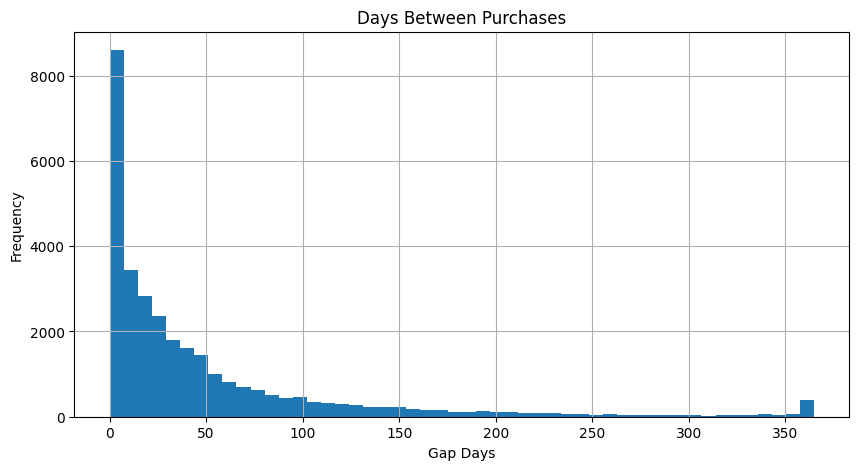

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

gaps["gap_days"].clip(upper=365).hist(
    bins=50
)

plt.title("Days Between Purchases")
plt.xlabel("Gap Days")
plt.ylabel("Frequency")

plt.show()

In [ ]:
retail.to_pickle(
    "/content/drive/MyDrive/Project files/retail_clean.pkl"
)

In [ ]:
!ls "/content/drive/MyDrive/Project files"

 Audit.ipynb
 Notebook_1_Data_Audit
'Notebook 2 – Snapshot Creation'
'Notebook 3 – Feature Engineering'
'Notebook 4 – Target Engineering'
'Notebook 5 – Model Development'
'Notebook 6 – Final Evaluation & Model Selection'
 online_retail_II.xlsx
 retail_clean.pkl
